Centering an scaling makes variables on different scales look similar.

29.27401578191827
2.8486761837737893


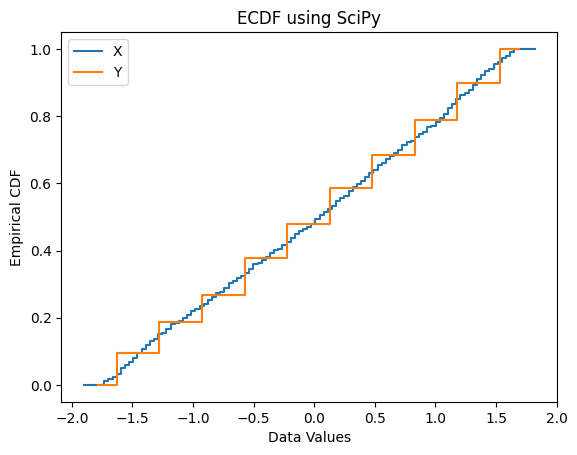

In [33]:
import random
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

X = [random.randint(1, 100) for _ in range(1000)]
X_star = (X - np.mean(X))/np.std(X)

print(np.std(X))

Y = [random.randint(1,10) for _ in range(1000)]
Y_star = (Y - np.mean(Y))/np.std(Y)
print(np.std(Y))

cdf_X = stats.ecdf(X_star)
cdf_Y = stats.ecdf(Y_star)
fig, ax = plt.subplots()
cdf_X.cdf.plot(ax, label='X')
cdf_Y.cdf.plot(ax, label='Y')

ax.set_xlabel("Data Values")
ax.set_ylabel("Empirical CDF")
ax.set_title("ECDF using SciPy")
plt.legend()
plt.show()

In [34]:
# import numpy as np
# import scipy.stats

# # 1. Initialize the random number generator
# rng = np.random.default_rng(seed=42)

# # 2. Define the mean vector (1D array of length N)
# mean = [1, 23]

# # 3. Define the covariance matrix (NxN symmetric, positive-semidefinite matrix)
# # This example introduces a strong positive correlation between the two dimensions
# cov = [[1, 0.8], 
#        [0.8, 1]]

# # 4. Draw 100 samples from the distribution
# samples_raw = rng.multivariate_normal(mean, cov, size=10)
# X = samples_raw[:,0]
# Y = samples_raw[:,1]

# corr_XY = np.corrcoef(X, Y)
# print("Correlation between X and Y:")
# print(corr_XY)


# # 5. Center and scale the samples
# X_star = (samples_raw[:, 0] - np.mean(samples_raw[:, 0])) / np.std(samples_raw[:, 0])
# Y_star = (samples_raw[:, 1] - np.mean(samples_raw[:, 1])) / np.std(samples_raw[:, 1])

# corr_XY_star = np.corrcoef(X_star, Y_star)
# print("Correlation between X* and Y*")
# print(corr_XY_star)


Making one variable a function of the other.

In [3]:
import numpy as np
import scipy.stats
rng = np.random.default_rng(seed=42)

Z = rng.normal(0,1, size=1000)
print(type(Z))
R = scipy.special.expit(Z-12)

corr_ZR = np.corrcoef(Z, R)
print("Correlation between Z and R:")
print(corr_ZR)

Z_star = (Z - np.mean(Z)) / np.std(Z)
R_star = (R - np.mean(R)) / np.std(R)

corr_ZR_star = np.corrcoef(Z_star, R_star)
print("Correlation between Z* and R*:")
print(corr_ZR_star)



<class 'numpy.ndarray'>
Correlation between Z and R:
[[1.        0.7812854]
 [0.7812854 1.       ]]
Correlation between Z* and R*:
[[1.        0.7812854]
 [0.7812854 1.       ]]


If we plot centered and scaled versions of data drawn from different distributions, they should have different looking cdfs

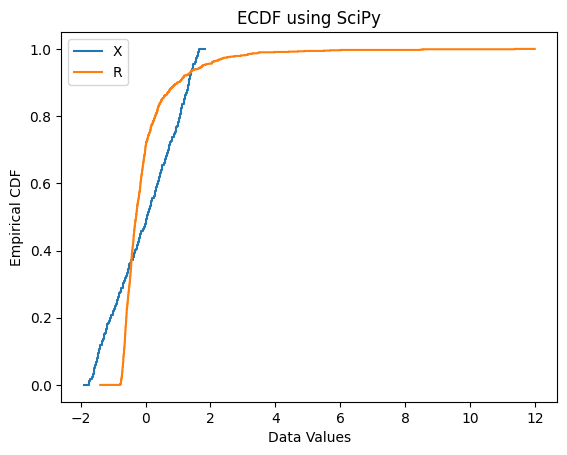

In [36]:
Z_star = (Z - np.mean(Z)) / np.std(Z)

cdf_X = stats.ecdf(X_star)
cdf_R = stats.ecdf(R_star)
fig, ax = plt.subplots()
cdf_X.cdf.plot(ax, label='X')
cdf_R.cdf.plot(ax, label='R')

ax.set_xlabel("Data Values")
ax.set_ylabel("Empirical CDF")
ax.set_title("ECDF using SciPy")
plt.legend()
plt.show()


Outcomes from the factor model can be correlated however we like.

In [40]:
import numpy as np

vectors = np.array([
    [10, 20, 30, 40],
    [12, 24, 28, 44],
    [14, 22, 32, 42]
])

print(vectors)

# rowvar=False treats each row as a separate vector/observation
cov_matrix = np.cov(vectors, rowvar=False)

print("Covariance Matrix:\n", cov_matrix)
print("Sample Variance (Diagonal):", np.diagonal(cov_matrix))

[[10 20 30 40]
 [12 24 28 44]
 [14 22 32 42]]
Covariance Matrix:
 [[ 4.  2.  2.  2.]
 [ 2.  4. -2.  4.]
 [ 2. -2.  4. -2.]
 [ 2.  4. -2.  4.]]
Sample Variance (Diagonal): [4. 4. 4. 4.]


In [194]:


# Generate time varying factors of dim 2
T = 7
factors_list = []
for t in range(T):
    # three options: 
    # # Perfectly correlated
    # f = [0.1 * t, 0.1*t]
    # # sum
    # f = [t + rng.normal(1,1, size=1)[0], t + rng.normal(-1,1, size=1)[0]]
    # product
    f = [t * rng.normal(1,1, size=1)[0], t * rng.normal(-1,1, size=1)[0]]
    factors_list.append(f)

factor_list = np.array(factors_list)

# create two loadings
lambda_1 = np.array([0.5,1.3])
lambda_2 = np.array([0.4,0.6])

# sample correlation
sample_variance = np.cov(factor_list,rowvar=False)
var_1 = lambda_1 @ sample_variance @ lambda_1
var_2 = lambda_2 @ sample_variance @ lambda_2
sample_covariance = np.dot(lambda_1, np.dot(sample_variance, lambda_2))
sample_correlation = sample_covariance / np.sqrt(var_1 * var_2)
print("Sample Correlation:", sample_correlation)

# multiply loadings by factors
outcome_1 = []
outcome_2 = []
for f in factors_list:
    outcome_1.append(np.dot(lambda_1, f))
    outcome_2.append(np.dot(lambda_2, f))

print("Correlation between outcomes BEFORE adding noise")
print(np.corrcoef(outcome_1, outcome_2))

outcome_1 = outcome_1 + rng.normal(0,1, size=len(outcome_1))
outcome_2 = outcome_2 + rng.normal(0,1, size=len(outcome_2))

print("Correlation between outcomes AFTER adding noise")
print(np.corrcoef(outcome_1, outcome_2))

Sample Correlation: 0.9803574987475939
Correlation between outcomes BEFORE adding noise
[[1.        0.9803575]
 [0.9803575 1.       ]]
Correlation between outcomes AFTER adding noise
[[1.         0.95423963]
 [0.95423963 1.        ]]
